# Tidal stripping sensitivity study

Runs the Du+24/25 density-evolution-law loop for:
* **Concentration sweep** — `cDekel0` ∈ {2, 5, 20, 100}, circular orbit.
* **Orbit sweep** — `cDekel0 = 20`, circularity η ∈ {0.3, 0.5, 0.7, 1.0}
  (η = 1 fully circular, η = 0.3 very eccentric).

Final plots compare tidal tracks and mass-loss histories across all runs.

In [1]:
import config as cfg
from profiles import NFW, Dekel, Vcirc, tdyn
from orbit import orbit
import evolve as ev
from subhalo_functions import heat_profile, NumericProfile, tidalTensor

import numpy as np
import time
import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 13
import matplotlib.pyplot as plt

%matplotlib inline

>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...


    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


In [2]:
cfg.Mres = 1e3

# host halo
Mv   = 1e9
cNFW = 11.68
potential = NFW(Mv, cNFW)

# subhalo shared params
mv0     = 1e6
aDekel0 = 1.0 + cfg.eps

# tidal heating parameters (same as stripping.ipynb)
epsh  = 3
gamma = 2.5

# fiducial starting position (same as stripping.ipynb)
R0, phi0, z0 = 1., 0., 1.
VR0, Vz0     = 0., 0.
Vcirc0 = Vcirc(potential, np.sqrt(R0**2 + z0**2), 0.)
print(f"Vcirc at r=sqrt({R0}^2+{z0}^2) = {Vcirc0:.3f} kpc/Gyr")

Vcirc at r=sqrt(1.0^2+1.0^2) = 16.793 kpc/Gyr


In [3]:
def evolve_profile(profile, dt, tidalHR, potential, xv):
    """Du+24/25 density evolution law (Eqs. 36-37) + mass-loss (Eq. 35)."""
    heated = heat_profile(profile, lambda r: dt * tidalHR * r**2)
    l_t = ev.ltidal(heated, potential, xv, 'King62')
    if l_t < heated.rh:
        M_in_lt = heated.M(l_t)
        T_loss  = 2.0 * np.pi * np.sqrt(l_t**3 / (16.0 * cfg.G * max(M_in_lt, 1.0)))
        dm      = max((heated.Mh - M_in_lt) * dt / T_loss, 0.0)
        m_new   = max(heated.Mh - dm, cfg.Mres)
    else:
        dm, m_new = 0.0, heated.Mh
    if m_new < heated.Mh and m_new > cfg.Mres:
        rf, M = heated.ri, heated.Mr
        k = min(np.searchsorted(M, m_new) + 1, len(rf))
        new_profile = NumericProfile(rf[:k], M[:k])
    else:
        new_profile = heated
    return new_profile, m_new, dm, l_t


def run_simulation(cDekel0, xv0, Nstep=1000, tmax=10.):
    """Run the Du+24/25 tidal evolution for a single set of initial conditions.

    Parameters
    ----------
    cDekel0 : float    Dekel concentration at infall
    xv0     : (6,)     initial phase-space vector [R, phi, z, VR, Vphi, Vz]
    Nstep   : int      number of timesteps
    tmax    : float    evolution time [Gyr]

    Returns
    -------
    dict with keys: timesteps, mass, rmax, vmax, rmax0, vmax0
    """
    s    = Dekel(mv0, cDekel0, aDekel0)
    rval = np.logspace(np.log10(cfg.Rres), np.log10(s.rh), 100)
    prof = NumericProfile(rval, s.M(rval))
    m    = mv0
    rmax0, vmax0 = prof.rmax, prof.Vmax

    r = np.sqrt(xv0[0]**2 + xv0[2]**2)

    timesteps = np.linspace(0., tmax, Nstep + 1)[1:]
    mass_arr  = np.zeros(Nstep)
    rmax_arr  = np.zeros(Nstep)
    vmax_arr  = np.zeros(Nstep)

    o      = orbit(xv0)
    tprev  = 0.
    tt_int = np.zeros((3, 3))

    for i, t in enumerate(timesteps):
        dt = t - tprev
        if r > cfg.Rres:
            o.integrate(t, potential, m)
            xv = o.xv
        else:
            tprev = t
            continue

        r = np.sqrt(xv[0]**2 + xv[2]**2)
        V = np.sqrt(xv[3]**2 + xv[4]**2 + xv[5]**2)
        x = xv[0] * np.cos(xv[1])
        y = xv[0] * np.sin(xv[1])
        z = xv[2]

        t_orb = tdyn(potential, r)
        if dt >= t_orb:
            tprev = t
            continue

        tt      = tidalTensor(potential, [x, y, z])
        tt_int += (tt - tt_int / t_orb) * dt
        tidalHR = (epsh / 3
                   * (1 + (2*np.pi*r / V / t_orb)**2)**(-gamma)
                   * np.sum(tt * tt_int))

        if m > cfg.Mres:
            try:
                prof, m, _, _ = evolve_profile(prof, dt, tidalHR, potential, xv)
            except RuntimeError:
                m = cfg.Mres
        else:
            m = cfg.Mres

        mass_arr[i] = m
        rmax_arr[i] = prof.rmax
        vmax_arr[i] = prof.Vmax
        tprev = t

    return dict(timesteps=timesteps, mass=mass_arr,
                rmax=rmax_arr, vmax=vmax_arr,
                rmax0=rmax0,   vmax0=vmax0)


def run_satgen(cDekel0, xv0, Nstep=1000, tmax=10.):
    """SatGen baseline tidal evolution using ev.msub + ev.Dekel.

    Parameters
    ----------
    cDekel0 : float    Dekel concentration at infall
    xv0     : (6,)     initial phase-space vector [R, phi, z, VR, Vphi, Vz]
    Nstep   : int      number of timesteps
    tmax    : float    evolution time [Gyr]

    Returns
    -------
    dict with keys: timesteps, mass, rmax, vmax, rmax0, vmax0
    """
    s     = Dekel(mv0, cDekel0, aDekel0)
    m     = mv0
    rmax0, vmax0 = s.rmax, s.Vmax

    r = np.sqrt(xv0[0]**2 + xv0[2]**2)

    timesteps = np.linspace(0., tmax, Nstep + 1)[1:]
    mass_arr  = np.zeros(Nstep)
    rmax_arr  = np.zeros(Nstep)
    vmax_arr  = np.zeros(Nstep)

    o     = orbit(xv0)
    tprev = 0.

    for i, t in enumerate(timesteps):
        dt = t - tprev
        if r > cfg.Rres:
            o.integrate(t, potential, m)
            xv = o.xv
        else:
            tprev = t
            continue

        r = np.sqrt(xv[0]**2 + xv[2]**2)

        if m > cfg.Mres:
            m, lt = ev.msub(s, potential, xv, dt, choice='King62', alpha=1.)
            a = s.alphah
            c_d, Delta = ev.Dekel(m, mv0, rmax0, vmax0, aDekel0, z=0.)
            s = Dekel(m, c_d, a, Delta=Delta, z=0.)
        else:
            m = cfg.Mres

        mass_arr[i] = m
        rmax_arr[i] = s.rmax
        vmax_arr[i] = s.Vmax
        tprev = t

    return dict(timesteps=timesteps, mass=mass_arr,
                rmax=rmax_arr, vmax=vmax_arr,
                rmax0=rmax0,   vmax0=vmax0)

In [4]:
xv0_circ = np.array([R0, phi0, z0, VR0, Vcirc0, Vz0])

concentrations = [2, 5, 20, 100]
results_conc = {}
for c in concentrations:
    print(f"  cDekel0 = {c:3d} ...", end=" ", flush=True)
    t0 = time.time()
    results_conc[c] = run_simulation(c, xv0_circ)
    print(f"{time.time()-t0:.1f} s")
print("done.")

  cDekel0 =   2 ... 

3.2 s
  cDekel0 =   5 ... 

3.2 s
  cDekel0 =  20 ... 

2.7 s
  cDekel0 = 100 ... 

1.4 s
done.


In [5]:
cDekel_sweep = 20
etas = [0.3, 0.5, 0.7, 1.0]
results_orb = {}
for eta in etas:
    xv0_eta = np.array([R0, phi0, z0, VR0, eta * Vcirc0, Vz0])
    print(f"  eta = {eta:.1f} ...", end=" ", flush=True)
    t0 = time.time()
    results_orb[eta] = run_simulation(cDekel_sweep, xv0_eta)
    print(f"{time.time()-t0:.1f} s")
print("done.")

  eta = 0.3 ... 

1.8 s
  eta = 0.5 ... 

2.0 s
  eta = 0.7 ... 

1.8 s
  eta = 1.0 ... 

2.7 s
done.


In [6]:
print("SatGen baseline — concentration sweep ...")
satgen_conc = {}
for c in concentrations:
    print(f"  cDekel0 = {c:3d} ...", end=" ", flush=True)
    t0 = time.time()
    satgen_conc[c] = run_satgen(c, xv0_circ)
    print(f"{time.time()-t0:.1f} s")

print("SatGen baseline — orbit sweep ...")
satgen_orb = {}
for eta in etas:
    xv0_eta = np.array([R0, phi0, z0, VR0, eta * Vcirc0, Vz0])
    print(f"  eta = {eta:.1f} ...", end=" ", flush=True)
    t0 = time.time()
    satgen_orb[eta] = run_satgen(cDekel_sweep, xv0_eta)
    print(f"{time.time()-t0:.1f} s")
print("done.")

SatGen baseline — concentration sweep ...
  cDekel0 =   2 ... 

0.1 s
  cDekel0 =   5 ... 

0.1 s
  cDekel0 =  20 ... 

0.1 s
  cDekel0 = 100 ... 

0.1 s
SatGen baseline — orbit sweep ...
  eta = 0.3 ... 

0.1 s
  eta = 0.5 ... 

0.1 s
  eta = 0.7 ... 

0.1 s
  eta = 1.0 ... 

0.1 s
done.


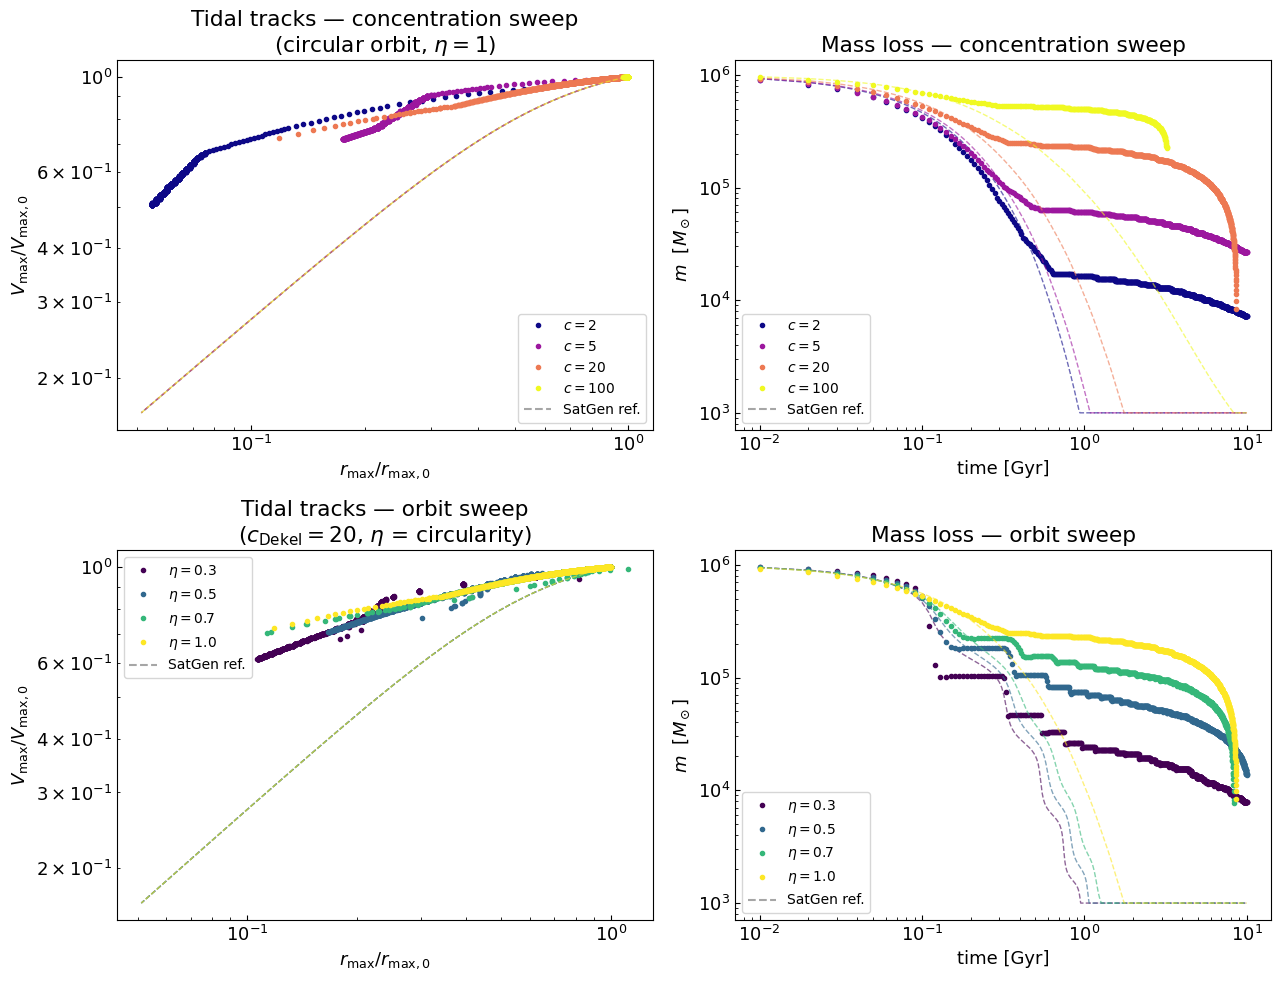

In [7]:
from matplotlib.lines import Line2D

cmap_c = plt.get_cmap('plasma')
cmap_o = plt.get_cmap('viridis')

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# proxy handle for the shared SatGen style
proxy_sg = Line2D([0], [0], linestyle='--', color='gray', alpha=0.7,
                  label='SatGen (ev.msub+ev.Dekel)')

# ── concentration sweep ──────────────────────────────────────────────────────
ax_tt_c = axes[0, 0]
ax_ml_c = axes[0, 1]
for k, c in enumerate(concentrations):
    res    = results_conc[c]
    sg     = satgen_conc[c]
    col    = cmap_c(k / max(len(concentrations) - 1, 1))
    mask_r = res['rmax'] > 0
    mask_t = res['mass'] > 0
    sg_mask_r = sg['rmax'] > 0
    sg_mask_t = sg['mass'] > 0
    # Du+24/25 (dots)
    ax_tt_c.plot(res['rmax'][mask_r] / res['rmax0'],
                 res['vmax'][mask_r] / res['vmax0'],
                 '.', color=col, label=f'$c={c}$')
    ax_ml_c.plot(res['timesteps'][mask_t], res['mass'][mask_t],
                 '.', color=col, label=f'$c={c}$')
    # SatGen reference (dashed)
    ax_tt_c.plot(sg['rmax'][sg_mask_r] / sg['rmax0'],
                 sg['vmax'][sg_mask_r] / sg['vmax0'],
                 '--', color=col, alpha=0.6, linewidth=1.)
    ax_ml_c.plot(sg['timesteps'][sg_mask_t], sg['mass'][sg_mask_t],
                 '--', color=col, alpha=0.6, linewidth=1.)

ax_tt_c.set_xscale('log'); ax_tt_c.set_yscale('log')
ax_tt_c.set_xlabel(r'$r_{\rm max}/r_{\rm max,0}$')
ax_tt_c.set_ylabel(r'$V_{\rm max}/V_{\rm max,0}$')
ax_tt_c.set_title('Tidal tracks — concentration sweep\n' r'(circular orbit, $\eta=1$)')
handles, labels = ax_tt_c.get_legend_handles_labels()
ax_tt_c.legend(handles=handles + [proxy_sg], labels=labels + ['SatGen ref.'], fontsize=10)

ax_ml_c.set_xscale('log'); ax_ml_c.set_yscale('log')
ax_ml_c.set_xlabel('time [Gyr]')
ax_ml_c.set_ylabel(r'$m$  [$M_\odot$]')
ax_ml_c.set_title('Mass loss — concentration sweep')
handles, labels = ax_ml_c.get_legend_handles_labels()
ax_ml_c.legend(handles=handles + [proxy_sg], labels=labels + ['SatGen ref.'], fontsize=10)

# ── orbit sweep ──────────────────────────────────────────────────────────────
ax_tt_o = axes[1, 0]
ax_ml_o = axes[1, 1]
for k, eta in enumerate(etas):
    res    = results_orb[eta]
    sg     = satgen_orb[eta]
    col    = cmap_o(k / max(len(etas) - 1, 1))
    mask_r = res['rmax'] > 0
    mask_t = res['mass'] > 0
    sg_mask_r = sg['rmax'] > 0
    sg_mask_t = sg['mass'] > 0
    # Du+24/25 (dots)
    ax_tt_o.plot(res['rmax'][mask_r] / res['rmax0'],
                 res['vmax'][mask_r] / res['vmax0'],
                 '.', color=col, label=rf'$\eta={eta:.1f}$')
    ax_ml_o.plot(res['timesteps'][mask_t], res['mass'][mask_t],
                 '.', color=col, label=rf'$\eta={eta:.1f}$')
    # SatGen reference (dashed)
    ax_tt_o.plot(sg['rmax'][sg_mask_r] / sg['rmax0'],
                 sg['vmax'][sg_mask_r] / sg['vmax0'],
                 '--', color=col, alpha=0.6, linewidth=1.)
    ax_ml_o.plot(sg['timesteps'][sg_mask_t], sg['mass'][sg_mask_t],
                 '--', color=col, alpha=0.6, linewidth=1.)

ax_tt_o.set_xscale('log'); ax_tt_o.set_yscale('log')
ax_tt_o.set_xlabel(r'$r_{\rm max}/r_{\rm max,0}$')
ax_tt_o.set_ylabel(r'$V_{\rm max}/V_{\rm max,0}$')
ax_tt_o.set_title(
    f'Tidal tracks — orbit sweep\n'
    rf'($c_{{\rm Dekel}}={cDekel_sweep}$, $\eta$ = circularity)')
handles, labels = ax_tt_o.get_legend_handles_labels()
ax_tt_o.legend(handles=handles + [proxy_sg], labels=labels + ['SatGen ref.'], fontsize=10)

ax_ml_o.set_xscale('log'); ax_ml_o.set_yscale('log')
ax_ml_o.set_xlabel('time [Gyr]')
ax_ml_o.set_ylabel(r'$m$  [$M_\odot$]')
ax_ml_o.set_title('Mass loss — orbit sweep')
handles, labels = ax_ml_o.get_legend_handles_labels()
ax_ml_o.legend(handles=handles + [proxy_sg], labels=labels + ['SatGen ref.'], fontsize=10)

plt.tight_layout()
plt.show()